# Case Study - Collared Floater

# Introduction

A **collared floater** pays a floating-rate coupon bounded by a floor and a cap:

$$\max(K_{\text{floor}},\; \min(r,\; K_{\text{cap}}))$$

It can be replicated with three instruments:

| Instrument | Position |
|------------|----------|
| Floating-rate note | +1 |
| Floor (strike = $K_{\text{floor}}$) | +1 |
| Cap (strike = $K_{\text{cap}}$) | -1 |

# Setup


In [75]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from scipy.stats import norm

# Data

Use the data from the following file.
* `../data/fiderivs_2025-03-10.xlsx`

In [76]:
DATE = '2025-03-10'
FILEIN = f'../data/fiderivs_{DATE}.xlsx'

curves = pd.read_excel(FILEIN, sheet_name='rate curves').set_index('tenor')
curves.style.format('{:.1%}').format_index('{:.2f}')

,swap rates,spot rates,discounts,forwards,flat vols
tenor,,,,,
0.25,4.2%,4.2%,99.0%,nan%,nan%
0.50,4.1%,4.1%,98.0%,4.0%,14.6%
0.75,4.0%,4.0%,97.1%,3.7%,16.9%
1.00,3.9%,3.9%,96.2%,3.6%,19.1%
1.25,3.8%,3.8%,95.4%,3.4%,22.2%
1.50,3.7%,3.7%,94.6%,3.4%,24.5%
1.75,3.7%,3.7%,93.8%,3.4%,26.1%
2.00,3.7%,3.7%,93.0%,3.5%,27.2%
2.25,3.6%,3.6%,92.2%,3.4%,27.9%


### Parameters


In [77]:
NOTIONAL = 100
T = 5                   # Maturity in years
CPNFREQ = 4             # Quarterly coupons
FREQ_CURVE = 4          # Quarterly compounding

BOUND_LOWER = 0.02      # 2% floor
BOUND_UPPER = 0.05      # 5% cap

# 1. Pricing the Components


### 1.1.

A floater with no credit spread trades at par. Record the floater value.

In [78]:
# floater at T = 5 years
floater_price = NOTIONAL 
print(f'price of floater: {floater_price}')

price of floater: 100


### 1.2.

Price the **floor** (strike = 2%) and the **cap** (strike = 5%).

Use the flat vol at the 5-year tenor from the `curves` table.

Report both prices.

In [79]:
def calc_cap_floor_price(strike, expiry, notional = 100, freq = 4, curve = curves, suffix = '', type = 'cap'):
    """
    Calculate the price of a cap or floor using the Black model.
    """
    vol = curves.loc[expiry, 'flat vols']
    t = 2/freq
    price = 0
    while t <= expiry:
        
        forward_rate = curve.loc[t, f'forwards{suffix}']
        effective_expiry = t - 1/freq
        d1 = (np.log(forward_rate / strike) + 0.5 * vol**2 * effective_expiry) / (vol * np.sqrt(effective_expiry))
        d2 = d1 - vol * np.sqrt(effective_expiry)
        discount_factor = curve.loc[t, f'discounts{suffix}']
        if type == 'cap':
            price += notional/freq * (forward_rate * norm.cdf(d1) - strike * norm.cdf(d2)) * discount_factor
        else:
            price += notional/freq * (strike * norm.cdf(-d2) - forward_rate * norm.cdf(-d1)) * discount_factor
        t += 1/freq
    return price





In [80]:
cap_price = calc_cap_floor_price(BOUND_UPPER, 5, type='cap')
floor_price = calc_cap_floor_price(BOUND_LOWER, 5, type='floor')

print(f'price of cap: {cap_price}')
print(f'price of floor: {floor_price}')

price of cap: 0.9773140911242577
price of floor: 0.2449109260457209


### 1.3.

Combine the three instruments into the replicating portfolio:
* +1 Floater
* +1 Floor (2%)
* -1 Cap (5%)

Report the NAV of each component and the total portfolio value.

Is the portfolio worth more or less than par? Why?


In [81]:
portfolio_price = floater_price + floor_price - cap_price
print(f'price of collared floater: {portfolio_price}')

# NAV of each component
nav_floater = floater_price 
nav_cap = cap_price 
nav_floor = floor_price 

print(f'NAV of floater: {nav_floater}')
print(f'NAV of cap: {nav_cap}')
print(f'NAV of floor: {nav_floor}')


price of collared floater: 99.26759683492146
NAV of floater: 100
NAV of cap: 0.9773140911242577
NAV of floor: 0.2449109260457209


- The portfolio is worth less than par as the value of cap is higher than the value of float. 
- Given the swap rate at T = 5 is 3.6% and the flat vol is at 28%, there is more chance for the cap to be ITM than the float, hence the price of cap is higher than the float contributing negatively to the portfolio.

# 2. Risk Analysis


### 2.1.

Calculate the **duration** of the portfolio numerically by applying a 1bp parallel shock to the spot curve.

Report the duration of each component and the portfolio.

In [82]:
def calc_forward_rates(curve, suffix = '', freq = 4):
    """
    Calculate the forward rates from the spot rates.
    """
    curve[f'forward_discounts{suffix}'] = curve[f'discounts{suffix}'] / curve[f'discounts{suffix}'].shift(1)
    curve[f'forwards{suffix}'] = np.power(curve[f'forward_discounts{suffix}'], -freq) - 1
    return curve

def calc_duration_portfolio(portfolio_price, curve=None, expiry=T, freq=FREQ_CURVE):
    """
    Calculate the duration of the portfolio using finite difference method.
    """
    # FIX: was `curve = curves.__deepcopy__()` as default argument -- evaluated once at
    # definition, so the same object would be mutated on every call. Deep-copy inside
    # the body guarantees a fresh starting curve on each invocation.
    if curve is None:
        curve = curves.__deepcopy__()
    else:
        curve = curve.__deepcopy__()

    delta = 0.0001

    curve['spot rates up'] = curve['spot rates'] + delta
    curve['discounts_up'] = 1 / (1 + curve['spot rates up'] / freq) ** (curve.index * freq)
    curve = calc_forward_rates(curve, suffix='_up', freq=freq)
    cap_up_price   = calc_cap_floor_price(BOUND_UPPER, expiry, curve=curve, suffix='_up', type='cap')
    floor_up_price = calc_cap_floor_price(BOUND_LOWER, expiry, curve=curve, suffix='_up', type='floor')
    price_up = floor_up_price - cap_up_price

    curve['spot rates down'] = curve['spot rates'] - delta
    curve['discounts_down'] = 1 / (1 + curve['spot rates down'] / freq) ** (curve.index * freq)
    curve = calc_forward_rates(curve, suffix='_down', freq=freq)
    cap_down_price   = calc_cap_floor_price(BOUND_UPPER, expiry, curve=curve, suffix='_down', type='cap')
    floor_down_price = calc_cap_floor_price(BOUND_LOWER, expiry, curve=curve, suffix='_down', type='floor')
    price_down = floor_down_price - cap_down_price

    # floater price is not affected by the change in interest rates
    duration       = (price_down - price_up) / (portfolio_price * 2 * delta)
    duration_cap   = (cap_down_price   - cap_up_price)   / (nav_cap   * 2 * delta)
    duration_floor = (floor_down_price - floor_up_price) / (nav_floor * 2 * delta)
    return duration, duration_cap, duration_floor

In [83]:
portfolio_duration, duration_cap, duration_floor = calc_duration_portfolio(portfolio_price)
print(f'duration of the portfolio: {portfolio_duration:.4f} years')
print(f'duration of the cap: {duration_cap:.4f} years')
print(f'duration of the floor: {duration_floor:.4f} years')

duration of the portfolio: 1.4014 years
duration of the cap: -117.0513 years
duration of the floor: 100.9262 years


### 2.2.

Calculate the **OAS** of the portfolio.

If the market quotes this note at par (100.00), what parallel shift to the spot curve would match that price?

Use `fsolve` to find the OAS.

In [84]:
def calc_portfolio_value(x, curve = curves, expiry = T, freq = FREQ_CURVE):
    """
    Calculate the value of the portfolio using the current curve.
    """
    # print(type(x[0]))
    curve = curve.__deepcopy__()
    curve['spot rates'] = curve['spot rates'] + x[0]
    curve['discounts'] = 1 / (1 + curve['spot rates'] / freq) ** (curve.index * freq)
    curve = calc_forward_rates(curve, suffix = '', freq = freq)
    price_cap = calc_cap_floor_price(BOUND_UPPER, expiry, curve = curve, suffix = '', type='cap')
    price_floor = calc_cap_floor_price(BOUND_LOWER, expiry, curve = curve, suffix = '', type='floor')
    price_floater = NOTIONAL
    portfolio_value = price_floater + price_floor - price_cap
    # print(f'portfolio value at OAS {x:.4f}: {portfolio_value:.4f}')
    return portfolio_value

OAS = fsolve(lambda x: calc_portfolio_value(x) - 100, [-0.02])[0]
print(f'OAS of the portfolio: {OAS*10000:.2f}bps')


OAS of the portfolio: -63.11bps


### 2.3.

Plot the portfolio value across a range of interest rate scenarios (shock the spot curve from -300bp to +300bp).

On your plot, mark the current rate, the floor (2%), and the cap (5%).

Describe what you see in terms of convexity.

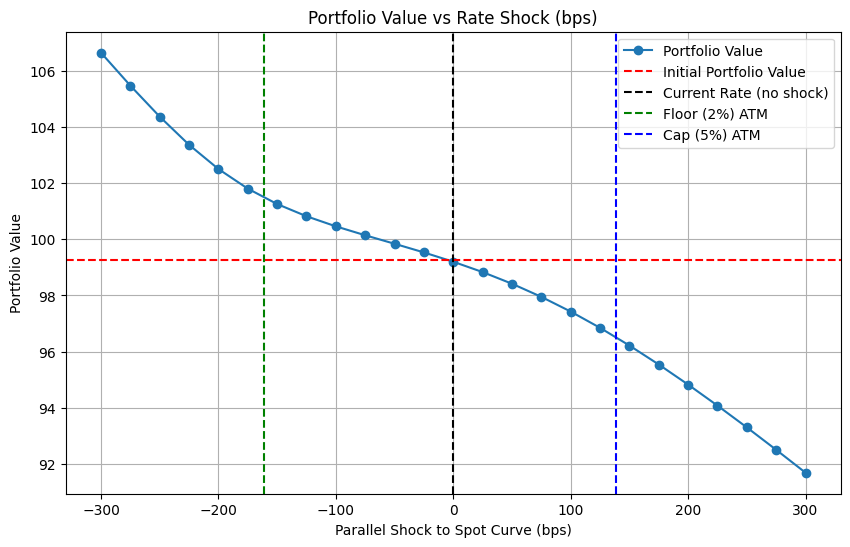

In [85]:
shocks = np.arange(-300, 301, 25) / 10000
portfolio_values = [calc_portfolio_value([shock]) for shock in shocks]

current_rate = curves.loc[T, 'swap rates']   # 5-year swap rate (decimal)

plt.figure(figsize=(10, 6))
plt.plot(shocks * 10000, portfolio_values, marker='o', label='Portfolio Value')
plt.axhline(portfolio_price, color='red',    linestyle='--', label='Initial Portfolio Value')
# FIX: was plt.axvline(current_rate, ...) -- passed the rate VALUE (~0.036) as an
# x-coordinate on a bps scale (-300 to 300), placing it at x≈0 by coincidence but
# semantically wrong. The "current rate" scenario is zero shock, so x=0.
plt.axvline(0,                                  color='black',  linestyle='--', label='Current Rate (no shock)')
# Mark the shock levels where the 5y rate would hit the floor/cap strikes
plt.axvline((BOUND_LOWER - current_rate)*10000, color='green',  linestyle='--', label=f'Floor ({BOUND_LOWER:.0%}) ATM')
plt.axvline((BOUND_UPPER - current_rate)*10000, color='blue',   linestyle='--', label=f'Cap ({BOUND_UPPER:.0%}) ATM')
plt.title('Portfolio Value vs Rate Shock (bps)')
plt.xlabel('Parallel Shock to Spot Curve (bps)')
plt.ylabel('Portfolio Value')
plt.legend()
plt.grid()
plt.show()

### Comments on convexity
- convexity is the second derivative of the portfolio value w.r.t. interest rate
- at ATM strike, the duration of the portfolio is changing a lesser rate than deep ITM or deep OTM rates. 
- the plot shows that in the shock range [-300, -200], [200, 300] the slope of the portofolio value curve is changing rapidly compared to the [-200, 200] range, impying that convexity is low in [-200, 200] range

# 3. Stress Test: A +300bp Shock


In 1994, the Federal Reserve raised rates roughly 300bp in under a year, causing large losses on structured note portfolios — most notably Orange County's $1.7 billion loss.

Orange County held primarily **inverse floaters** (coupon = Fixed Rate $-$ Multiplier $\times$ Floating Rate), which are more aggressive than a collared floater. But it is instructive to see what a +300bp shock does to our product.


### 3.1.

Compute the portfolio value after a +300bp parallel shock to the spot curve.

Report the percentage loss.

In [86]:
portfolio_price_300bp = calc_portfolio_value([0.03])
loss_percentage = (portfolio_price - portfolio_price_300bp) / portfolio_price * 100
print(f'portfolio value after 300bp shock: {portfolio_price_300bp:.4f}')
print(f'loss percentage after 300bp shock: {loss_percentage:.2f}%')

portfolio value after 300bp shock: 91.6900
loss percentage after 300bp shock: 7.63%


### 3.2.

Orange County's investment pool was leveraged roughly 2.5x.

If we apply the same leverage to the loss from 3.1, what is the leveraged loss?

How does it compare to Orange County's actual 22.3% loss? Why is the gap so large?


In [87]:
leverage = 2.5
orange_county_loss_percentage = 22.3
leverage_loss_percentage = loss_percentage * leverage
print(f'loss percentage after 300bp shock with leverage {leverage}: {leverage_loss_percentage:.2f}%')

print(f'there is a diff in the leveraged loss and orange county\'s loss by {orange_county_loss_percentage - leverage_loss_percentage:.2f}%')

loss percentage after 300bp shock with leverage 2.5: 19.08%
there is a diff in the leveraged loss and orange county's loss by 3.22%


Three is a difference in the product dynamics of inverse floater(used by orange county) vs collared floater. This should be one of the reasons why there is a difference between the loss percentages
- Inverse floater payoff = (K - L * Rate), K is fixed strike and L is the leverage
- Collared Floater payoff = max(K_floor, min(rate, K_cap))

# 4. Optional: Volatility Skew

*Requires SABR (Chapter 8).*

### 4.1.

The analysis above uses a single flat vol for both the cap and floor. In practice, implied volatility varies with strike.

Using the SABR parameters below (estimated in `E.8.2. SABR Calibration`), compute the SABR-implied vol at each strike (2% and 5%).

| Parameter | Value |
|-----------|-------|
| beta | 0.25 |
| alpha | 0.0214 |
| nu | 0.60 |
| rho | -0.20 |

Use the 5-year forward rate as the forward.


### 4.2.

Re-price the floor and cap using the SABR-implied vols (one vol per instrument).

Compare the flat-vol portfolio value to the SABR-adjusted portfolio value. Which direction does the skew push the price, and why?


Part 2 (C.9.1) values the same product using binomial trees.